In [2]:
import kagglehub

path = kagglehub.competition_download(
    "house-prices-advanced-regression-techniques"
)

print(path)

100%|██████████| 199k/199k [00:00<00:00, 755kB/s]

Extracting files...
C:\Users\USER\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques


House Prices - Advanced
Regression Techniques


In [3]:
import os

print(os.listdir(path))

['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


In [4]:
import pandas as pd

df = pd.read_csv(path + "\\train.csv")

In [8]:
mean_price = df["SalePrice"].mean()
std_price = df["SalePrice"].std()

print (f"Mean: {mean_price:.2f}")
print (f"Std: {std_price:.2f}")

df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

Mean: 180921.20
Std: 79442.50


SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

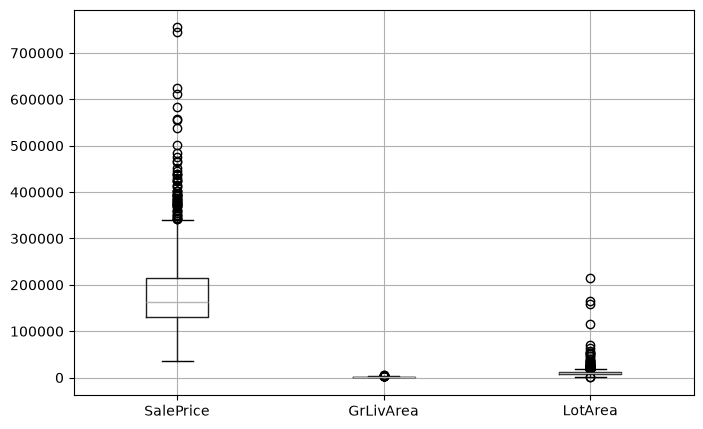

In [12]:
import matplotlib.pyplot as plt

df[["SalePrice", "GrLivArea", "LotArea"]].boxplot(figsize=(8,5))
plt.show()

In [13]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

x = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

cat_cols = x.select_dtypes(include=["object"]).columns
num_cols = x.select_dtypes(exclude=["object"]).columns

cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessing = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, cat_cols),
        ("num", num_pipeline, num_cols)
    ]
)

model = LinearRegression()

pipe = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", model)
    ]
)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

C:\Users\USER\AppData\Local\Temp\ipykernel_32060\2992589165.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include=["object"]).columns


MSE: 868811281.5739096
RMSE: 29475.604855098558
R2: 0.8867308562757305


In [14]:
df[["GrLivArea", "TotRmsAbvGrd"]].corr()

,GrLivArea,TotRmsAbvGrd
GrLivArea,1.000000,0.825489
TotRmsAbvGrd,0.825489,1.000000


In [16]:
df["price_per_m2"] = df["SalePrice"] / df["GrLivArea"]

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)